In [26]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from itertools import product 
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

df = pd.read_csv("df_hmm_var.csv", parse_dates=["date"])
df = df[df["hmm_regime"] != -1].reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nRegime distribution:")
print(df['hmm_regime'].value_counts().sort_index())

Dataset shape: (3489, 49)
Date range: 2016-07-14 00:00:00 to 2026-01-31 00:00:00

Regime distribution:
hmm_regime
0.0    1975
1.0    1149
Name: count, dtype: int64


In [27]:
# Use ALL available features (matching baseline SVR-L)
# Exclude only: date, targets, and raw volatility/variance (we have rolling versions)
exclude_cols = [
    'date', 
    'target_vol', 
    'target_var', 
    'realized_volatility', 
    'realized_variance'
    'rvol_1',
    'rvol_2',
    'rvol_3',
    'rvol_7',
    'rvol_30',
    'hmm_regime',           
    'hmm_regime_lag1',
    "hmm_prob_high_lag1",
    "hmm_prob_high_lag2",
    "hmm_prob_high_roll5"       
]

# Get all features
all_cols = df.columns.tolist()
svr_features = [col for col in all_cols if col not in exclude_cols]

print(f"\nTotal SVR features: {len(svr_features)}")
print(f"Features: {svr_features}")

# Check for missing values
print(f"\nMissing values in SVR features:")
missing_counts = df[svr_features + ['target_var']].isnull().sum()
print(missing_counts[missing_counts > 0])

# Remove rows with NaN
df_clean = df.dropna(subset=svr_features + ['target_var']).reset_index(drop=True)

print(f"\nAfter removing NaN: {df_clean.shape}")
print(f"\nFeature summary (first 10 features):")
print(df_clean[svr_features[:10]].describe())


Total SVR features: 36
Features: ['log_return', 'realized_variance', 'gtrend_pct_change', 'blockchain_diff_log_n_transactions', 'blockchain_diff_log_transaction_fee_usd', 'blockchain_diff_log_n_unique_addresses', 'blockchain_diff_log_transaction_volume_usd', 'log_volume', 'gold_close_ret', 'silver_close_ret', 'brent_close_ret', 'dji_close_ret', 'spx_close_ret', 'rut_close_ret', 'nasdaq_close_ret', 'usdcny_close_ret', 'usdeur_close_ret', 'gold_volume_chg', 'silver_volume_chg', 'brent_volume_chg', 'dji_volume_chg', 'spx_volume_chg', 'rut_volume_chg', 'nasdaq_volume_chg', 'vix_close_chg', 'hash-rate_chg', 'difficulty_chg', 'median-confirmation-time_chg', 'blockchain_log_mempool_count_chg', 'rvar_1', 'rvar_2', 'rvar_3', 'rvar_7', 'rvar_30', 'rvol_1', 'hmm_prob_high']

Missing values in SVR features:
hmm_prob_high    365
target_var         1
dtype: int64

After removing NaN: (3124, 49)

Feature summary (first 10 features):
        log_return  realized_variance  gtrend_pct_change  \
count  

In [28]:
# 60/25/15 split
total_len = len(df_clean)
train_size = int(total_len * 0.60)
val_size = int(total_len * 0.25)

train_end = train_size
val_start = train_size
val_end = train_size + val_size
test_start = val_end

print(f"Train: {0:4d} to {train_end:4d} ({train_size:4d} days) | {df_clean['date'].iloc[0]} to {df_clean['date'].iloc[train_end-1]}")
print(f"Val:   {val_start:4d} to {val_end:4d} ({val_size:4d} days) | {df_clean['date'].iloc[val_start]} to {df_clean['date'].iloc[val_end-1]}")
print(f"Test:  {test_start:4d} to {total_len:4d} ({total_len - test_start:4d} days) | {df_clean['date'].iloc[test_start]} to {df_clean['date'].iloc[-1]}")

window_size = 365
print(f"\nModel: SVR with linear kernel")
print(f"Rolling window: {window_size} days")

Train:    0 to 1874 (1874 days) | 2017-07-13 00:00:00 to 2022-08-29 00:00:00
Val:   1874 to 2655 ( 781 days) | 2022-08-30 00:00:00 to 2024-10-18 00:00:00
Test:  2655 to 3124 ( 469 days) | 2024-10-19 00:00:00 to 2026-01-30 00:00:00

Model: SVR with linear kernel
Rolling window: 365 days


In [ ]:
# Grid search for C and epsilon
import time

C_values = [0.1, 1.0, 10.0, 100.0]
epsilon_values = [0.001, 0.01, 0.1]

val_sample_indices = range(val_start, val_end, 5)
valid_indices = [i for i in val_sample_indices if i >= window_size]
grid_results = []
total_configs = len(C_values) * len(epsilon_values)

print(f"Testing {total_configs} configurations on {len(valid_indices)} samples...")
print(f"Total features: {len(svr_features)}")
print(f"Window size: {window_size} days")

start_time = time.time()
config_num = 0

for C, epsilon in product(C_values, epsilon_values):
    config_num += 1
    config_start = time.time()
    
    preds = []
    actuals = []
    
    for i in valid_indices:  # Use pre-filtered list (slightly faster)
        train_X = df_clean.iloc[i - window_size : i][svr_features].values
        train_y = df_clean.iloc[i - window_size : i]['target_var'].values
        
        test_X = df_clean.iloc[i:i+1][svr_features].values
        target_val = df_clean.iloc[i]['target_var']
        
        try:
            # Scale features AND target
            scaler_X = StandardScaler()
            scaler_y = StandardScaler()
            
            train_X_scaled = scaler_X.fit_transform(train_X)
            train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
            test_X_scaled = scaler_X.transform(test_X)
            
            # Fit SVR with current hyperparameters
            model = SVR(kernel='linear', C=C, epsilon=epsilon, max_iter=1000)  # Add max_iter
            model.fit(train_X_scaled, train_y_scaled)
            
            # Predict and inverse transform
            pred_scaled = model.predict(test_X_scaled)[0]
            pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
            pred = np.clip(pred, 0, 0.15**2)  # Clip for variance (squared)
            
            preds.append(pred)
            actuals.append(target_val)
            
        except Exception as e:
            fallback = preds[-1] if preds else 0.0004  # Fallback for variance (~0.02^2)
            preds.append(fallback)
            actuals.append(target_val)
    
    if len(preds) > 0:
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        grid_results.append({'C': C, 'epsilon': epsilon, 'RMSE': rmse})
    
    # Timing diagnostics
    config_time = time.time() - config_start
    elapsed = time.time() - start_time
    estimated_total = elapsed / config_num * total_configs
    remaining = estimated_total - elapsed
    
    print(f"Config {config_num}/{total_configs}: C={C:6.1f}, ε={epsilon:5.3f}, RMSE={rmse:.8f} | "
          f"{config_time:5.1f}s | ETA: {remaining/60:4.1f}min")

results_df = pd.DataFrame(grid_results).sort_values('RMSE')

print("\n" + "="*60)
print("TOP 10 CONFIGURATIONS")
print("="*60)
print(results_df.head(10).to_string(index=False))

best_config = results_df.iloc[0]
best_C = best_config['C']
best_epsilon = best_config['epsilon']

print(f"\n" + "="*60)
print("BEST CONFIGURATION")
print("="*60)
print(f"C:       {best_C}")
print(f"epsilon: {best_epsilon}")
print(f"Validation RMSE: {best_config['RMSE']:.8f}")  # More decimals for variance
print("="*60)

Testing 12 configurations on 157 samples...
Total features: 36
Window size: 365 days


Config 1/12: C=   0.1, ε=0.001, RMSE=0.00091997 |   6.7s | ETA:  1.2min
Config 2/12: C=   0.1, ε=0.010, RMSE=0.00091610 |   3.1s | ETA:  0.8min
Config 3/12: C=   0.1, ε=0.100, RMSE=0.00091524 |   2.9s | ETA:  0.6min
Config 4/12: C=   1.0, ε=0.001, RMSE=0.00093352 |   3.4s | ETA:  0.5min
Config 5/12: C=   1.0, ε=0.010, RMSE=0.00095004 |   4.9s | ETA:  0.5min
Config 6/12: C=   1.0, ε=0.100, RMSE=0.00095140 |   2.9s | ETA:  0.4min
Config 7/12: C=  10.0, ε=0.001, RMSE=0.00142568 |   2.8s | ETA:  0.3min
Config 8/12: C=  10.0, ε=0.010, RMSE=0.00134990 |   3.2s | ETA:  0.2min
Config 9/12: C=  10.0, ε=0.100, RMSE=0.00127995 |   3.7s | ETA:  0.2min
Config 10/12: C= 100.0, ε=0.001, RMSE=0.00214283 |   4.1s | ETA:  0.1min
Config 11/12: C= 100.0, ε=0.010, RMSE=0.00187075 |   5.9s | ETA:  0.1min
Config 12/12: C= 100.0, ε=0.100, RMSE=0.00177814 |   5.0s | ETA:  0.0min

Completed in 0.8 minutes

TOP 10 CONFIGURATIONS
    C  epsilon     RMSE
  0.1    0.100 0.000915
  0.1    0.010 0.000916
  0.1    0.0

In [30]:
best_C = 0.1
best_epsilon = 0.1

In [31]:
val_preds = []
val_actuals = []
val_dates = []
failures = 0

print(f"\nRunning full validation with C={best_C}, epsilon={best_epsilon}...")

for i in range(val_start, val_end):
    if i < window_size:
        continue
    
    train_X = df_clean.iloc[i - window_size : i][svr_features].values
    train_y = df_clean.iloc[i - window_size : i]['target_var'].values
    
    test_X = df_clean.iloc[i:i+1][svr_features].values
    target_val = df_clean.iloc[i]['target_var']
    current_date = df_clean.iloc[i]['date']
    
    try:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        train_X_scaled = scaler_X.fit_transform(train_X)
        train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
        test_X_scaled = scaler_X.transform(test_X)
        
        model = SVR(kernel='linear', C=best_C, epsilon=best_epsilon)
        model.fit(train_X_scaled, train_y_scaled)
        
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        pred = np.clip(pred, 0, 0.15)
        
        val_preds.append(pred)
        val_actuals.append(target_val)
        val_dates.append(current_date)
        
    except:
        failures += 1
        fallback = val_preds[-1] if val_preds else 0.02
        val_preds.append(fallback)
        val_actuals.append(target_val)
        val_dates.append(current_date)


Running full validation with C=0.1, epsilon=0.1...


In [32]:
val_preds = np.array(val_preds)
val_actuals = np.array(val_actuals)

val_rmse = np.sqrt(mean_squared_error(val_actuals, val_preds))
val_mae = mean_absolute_error(val_actuals, val_preds)
val_qlike = np.mean(val_actuals / (val_preds + 1e-10) - np.log(val_actuals / (val_preds + 1e-10)) - 1)


print(f"\n--- VALIDATION RESULTS ---")
print(f"RMSE:  {val_rmse:.6f}")
print(f"MAE:   {val_mae:.6f}")
print(f"QLIKE:   {val_qlike:.6f}")
print(f"Failures: {failures}")
print(f"Samples: {len(val_preds)}")


--- VALIDATION RESULTS ---
RMSE:  0.000859
MAE:   0.000434
QLIKE:   29217.767383
Failures: 0
Samples: 781


In [33]:
test_preds = []
test_actuals = []
test_dates = []
failures_test = 0

print(f"\nRunning test set evaluation...")

for i in range(test_start, total_len):
    if i < window_size:
        continue
    
    train_X = df_clean.iloc[i - window_size : i][svr_features].values
    train_y = df_clean.iloc[i - window_size : i]['target_var'].values
    
    test_X = df_clean.iloc[i:i+1][svr_features].values
    target_val = df_clean.iloc[i]['target_var']
    current_date = df_clean.iloc[i]['date']
    
    try:
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        
        train_X_scaled = scaler_X.fit_transform(train_X)
        train_y_scaled = scaler_y.fit_transform(train_y.reshape(-1, 1)).ravel()
        test_X_scaled = scaler_X.transform(test_X)
        
        model = SVR(kernel='linear', C=best_C, epsilon=best_epsilon)
        model.fit(train_X_scaled, train_y_scaled)
        
        pred_scaled = model.predict(test_X_scaled)[0]
        pred = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        pred = np.clip(pred, 0, 0.15)
        
        test_preds.append(pred)
        test_actuals.append(target_val)
        test_dates.append(current_date)
        
    except:
        failures_test += 1
        fallback = test_preds[-1] if test_preds else 0.02
        test_preds.append(fallback)
        test_actuals.append(target_val)
        test_dates.append(current_date)


Running test set evaluation...


In [34]:
test_preds = np.array(test_preds)
test_actuals = np.array(test_actuals)

test_rmse = np.sqrt(mean_squared_error(test_actuals, test_preds))
test_mae = mean_absolute_error(test_actuals, test_preds)
test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

print(f"\n--- TEST RESULTS ---")
print(f"RMSE:  {test_rmse:.6f}")
print(f"MAE:   {test_mae:.6f}")
print(f"QLIKE:   {test_qlike:.6f}")
print(f"Failures: {failures_test}")
print(f"Samples: {len(test_preds)}")


--- TEST RESULTS ---
RMSE:  0.000626
MAE:   0.000357
QLIKE:   8545.629412
Failures: 0
Samples: 469


In [35]:
summary = pd.DataFrame({
    'Dataset': ['Validation', 'Test'],
    'RMSE': [val_rmse, test_rmse],
    'MAE': [val_mae, test_mae],
    'QLIKE': [val_qlike,test_qlike],
    'Samples': [len(val_preds), len(test_preds)]
})

print("\n" + "="*60)
print("HMM-SVR-L Summary")
print("="*60)
print(summary.to_string(index=False))
print("="*60)
print(f"\nBest Parameters Used:")
print(f"  C: {best_C}")
print(f"  epsilon: {best_epsilon}")
print(f"  Features: {len(svr_features)}")
print("="*60)

# Save results
val_results = pd.DataFrame({
    'date': val_dates,
    'actual': val_actuals,
    'forecast': val_preds,
    'error': val_actuals - val_preds
})

test_results = pd.DataFrame({
    'date': test_dates,
    'actual': test_actuals,
    'forecast': test_preds,
    'error': test_actuals - test_preds
})



HMM-SVR-L Summary
   Dataset     RMSE      MAE        QLIKE  Samples
Validation 0.000859 0.000434 29217.767383      781
      Test 0.000626 0.000357  8545.629412      469

Best Parameters Used:
  C: 0.1
  epsilon: 0.1
  Features: 36


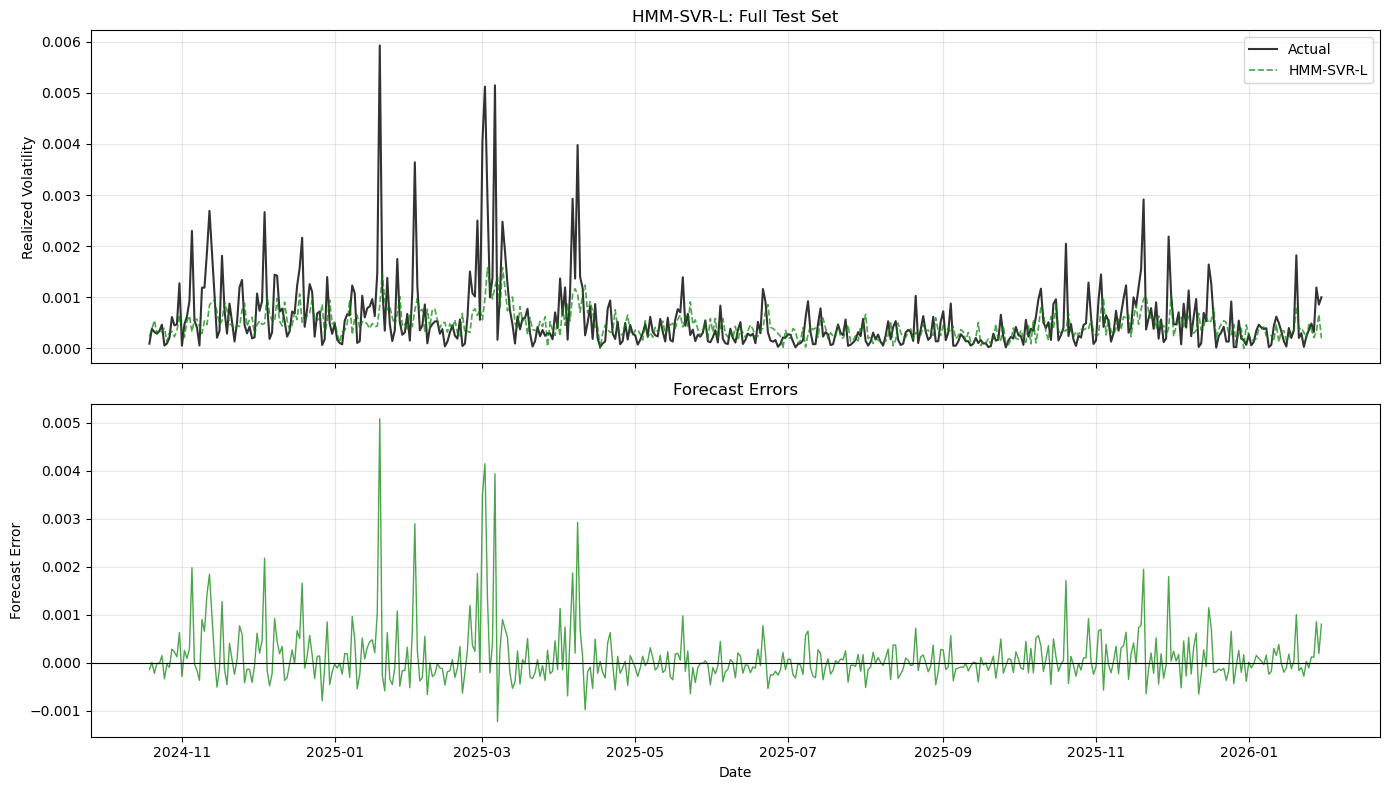

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

plot_n = len(test_actuals)
plot_dates = test_dates[-plot_n:]
plot_actuals = test_actuals[-plot_n:]
plot_forecasts = test_preds[-plot_n:]

# Panel 1: Actual vs Forecast
axes[0].plot(plot_dates, plot_actuals, label='Actual', color='black', linewidth=1.5, alpha=0.8)
axes[0].plot(plot_dates, plot_forecasts, label='HMM-SVR-L', color='green', linewidth=1.2, alpha=0.7, linestyle='--')
axes[0].set_ylabel('Realized Volatility')
axes[0].set_title(f'HMM-SVR-L: Full Test Set')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: Forecast Errors
errors = plot_actuals - plot_forecasts
axes[1].plot(plot_dates, errors, color='green', linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Forecast Error')
axes[1].set_xlabel('Date')
axes[1].set_title('Forecast Errors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

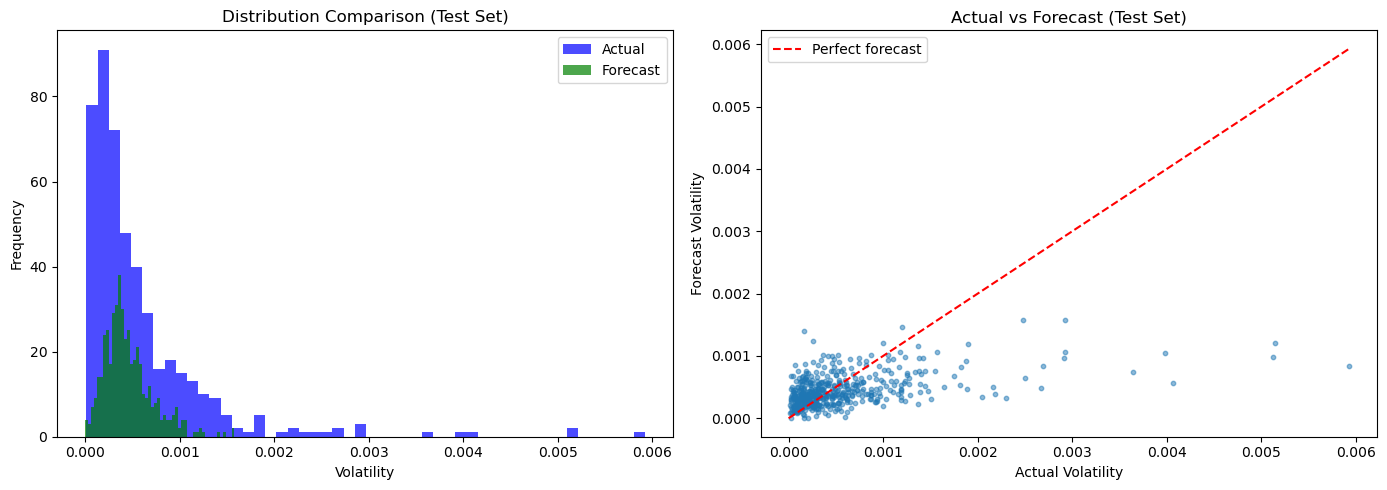


Forecast Statistics (Test Set):
  Mean forecast: 0.000454
  Mean actual:   0.000571
  Forecast std:  0.000256
  Actual std:    0.000689
  Forecasts > Actuals: 52.9%


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
axes[0].hist(test_actuals, bins=50, alpha=0.7, label='Actual', color='blue')
axes[0].hist(test_preds, bins=50, alpha=0.7, label='Forecast', color='green')
axes[0].set_xlabel('Volatility')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution Comparison (Test Set)')
axes[0].legend()

# Actual vs Forecast scatter
axes[1].scatter(test_actuals, test_preds, alpha=0.5, s=10)
axes[1].plot([0, test_actuals.max()], [0, test_actuals.max()], 'r--', label='Perfect forecast')
axes[1].set_xlabel('Actual Volatility')
axes[1].set_ylabel('Forecast Volatility')
axes[1].set_title('Actual vs Forecast (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nForecast Statistics (Test Set):")
print(f"  Mean forecast: {test_preds.mean():.6f}")
print(f"  Mean actual:   {test_actuals.mean():.6f}")
print(f"  Forecast std:  {test_preds.std():.6f}")
print(f"  Actual std:    {test_actuals.std():.6f}")
print(f"  Forecasts > Actuals: {(test_preds > test_actuals).mean()*100:.1f}%")